# 01_回归算法-多项式回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们来聊聊多项式回归。

多项式回归其实就是在做回归分析时，不再用一条直线来“连接”数据，而是用一条曲线（比如二次曲线、三次曲线等）来更好地描述数据之间的关系。

首先，回归就是在数据中找出一种“规律”或“趋势”，比如用一条直线来描述两个变量之间的关系。这种方法叫做线性回归。

**那么直线不够用怎么办？**

有些数据的关系不是直线那样简单，而是弯弯曲曲的。如果你用直线去描述这样的数据，可能就会“跑偏”，预测得不准。这时候就需要用曲线来描述数据的变化。

**多项式回归的思路**

多项式回归就是在直线的基础上，加上曲线的“弯曲”部分。比如用一个二次方（平方项）或者三次方（立方项）来“弯曲”你的模型，这样它就能更灵活地跟数据走了。

**举个例子**

假设你在研究一天中不同时间段的气温变化，通常气温不会一直直线上升或下降，而是先上升后下降。如果用直线去拟合，肯定无法反映这种变化。多项式回归可以用一个弯曲的曲线来描述气温的变化趋势，从而更准确地反映现实情况。

**为什么有用？**

多项式回归能捕捉数据中的非线性关系，使得模型在面对复杂数据时，预测效果更好。但同时需要注意，如果多项式的次数过高，可能会出现“过拟合”，也就是模型在训练数据上表现得很好，但对新数据预测效果却不理想。

## 原理详解

### 1. 模型的基本假设与数学形式

在传统的**线性回归**中，我们假设因变量 $y$和自变量 $x$之间的关系可以用一个线性模型来表示：  
$y = \beta_0 + \beta_1 x + \varepsilon,$  
其中 $\beta_0, \beta_1$为待估计的参数，$\varepsilon$ 是误差项。

而在**多项式回归**中，我们假定 $y$与 $x$之间的关系可以用一个多项式来描述：  
$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d + \varepsilon.$  
其中 $d$表示多项式的阶数，$\beta_0, \beta_1, \ldots, \beta_d$为模型参数。

> **关键点**：虽然模型中包含了 $x$的高次项，但模型对于参数仍然是线性的，即模型是关于参数 $\beta_i$ 的线性组合。

### 2. 构造设计矩阵与目标函数

假设我们有 $n$个样本，每个样本记为 $(x_i, y_i)$( $i=1,2,\ldots,n$)，为了方便表示，我们引入**设计矩阵** $X$：


$$
X = \begin{pmatrix}1 & x_1 & x_1^2 & \cdots & x_1^d \\1 & x_2 & x_2^2 & \cdots & x_2^d \\\vdots & \vdots & \vdots & \ddots & \vdots \\1 & x_n & x_n^2 & \cdots & x_n^d \\\end{pmatrix},
$$


以及参数向量和目标向量：


$$
\beta = \begin{pmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_d \end{pmatrix}, \quady = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix}.
$$


模型可以写作：


$$
y = X\beta + \varepsilon.
$$


为了估计参数 $\beta$，通常采用最小二乘法，构造目标函数（损失函数）为残差平方和：


$$
J(\beta) = \sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)^2 = \| y - X\beta \|^2.
$$


### 3. 最小二乘估计的推导

我们的目标是找到一组参数 $\beta$ 使得目标函数 $J(\beta)$最小。

令：


$$
J(\beta) = (y - X\beta)^T (y - X\beta).
$$


##### 求导并设梯度为零

对 $\beta$ 求偏导：


$$
\frac{\partial J}{\partial \beta} = -2 X^T (y - X\beta).
$$


令梯度为零：


$$
X^T (y - X\beta) = 0.
$$


整理得**正规方程**（Normal Equation）：


$$
X^T X \beta = X^T y.
$$


假设 $X^T X$可逆，则解为：


$$
\beta = (X^T X)^{-1} X^T y.
$$


> **注意**：当多项式次数较高时，设计矩阵中的列可能存在多重共线性问题，这会导致 $X^T X$条件数很大甚至不可逆，此时可能需要正则化方法（如岭回归）来缓解问题。

### 4. 算法流程

基于以上数学推导，多项式回归的一般算法流程可以细化为以下几个步骤：

**数据预处理**：

1. **数据收集**：获得 $n$个样本数据 $(x_i, y_i)$。
2. **数据清洗**：处理缺失值、异常值，确保数据质量。

**特征扩展（构造多项式特征）**：

1. 对每个自变量 $x_i$，生成多项式特征：$[1, x_i, x_i^2, \ldots, x_i^d].$
2. 构造设计矩阵 $X$（每一行对应一个样本，每一列对应一个多项式项）。

> **说明**：这里“1”代表常数项，对应参数 $\beta_0$。

**模型求解**：

1. **构造目标函数**：损失函数 $J(\beta) = \| y - X\beta \|^2$。
2. **求解正规方程**：计算 $\beta = (X^T X)^{-1} X^T y$得到最优参数。

   - 若 $X^T X$不可逆或条件不好，可采用数值优化方法（如梯度下降）或者正则化方法（如岭回归）来求解。

**模型评估**：

1. **残差分析**：计算残差 $y_i - \hat{y}_i$，分析模型拟合情况。
2. **性能指标**：例如均方误差（MSE）、决定系数 $R^2$等，用于衡量模型的拟合效果。
3. **交叉验证**：通过数据分割或交叉验证，防止过拟合现象，确保模型对新数据具有较好的泛化能力。

**模型调优**：

1. **多项式次数选择**：通过验证集或交叉验证选择最优的多项式阶数 $d$。
2. **正则化**：如果模型过拟合，可采用正则化技术（如岭回归、Lasso回归）对参数进行约束。
3. **特征缩放**：高次项可能导致数值计算不稳定，采用归一化或标准化技术可提高数值稳定性。

## 完整案例

咱们通过构造一个带噪声的非线性数据集，应用多项式回归（结合Ridge正则化优化）进行拟合，并使用网格搜索选择最佳的多项式阶数和正则化参数，最后做详细的数据分析和可视化。

Best parameters: {'polynomialfeatures__degree': 2, 'ridge__alpha': 0.001}
Best CV MSE: 0.14775954010384518
Test MSE: 0.152840012222148
Test R2 Score: 0.736230498202047


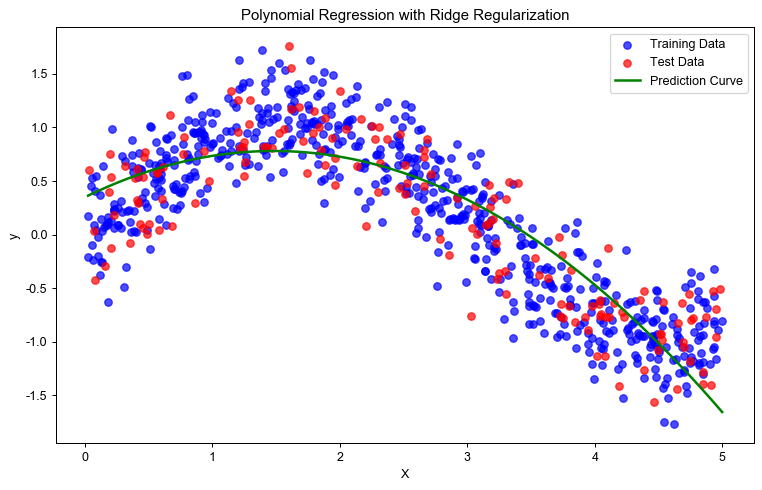

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. 数据生成与预处理
np.random.seed(42)

# 生成80个自变量样本，范围在[0,5]内，并按升序排列
X = np.sort(5 * np.random.rand(800, 1), axis=0)

# 根据非线性函数生成因变量，并加入正态分布噪声模拟真实数据
y = np.sin(X).ravel() + np.random.normal(scale=0.3, size=X.shape[0])

# 将数据划分为训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 构建多项式回归模型及优化
# 使用Pipeline将多项式特征转换和Ridge正则化组合在一起
# 通过多项式特征转换，可以捕捉数据的非线性关系；
# 通过Ridge正则化（岭回归）可以防止模型过拟合问题

# 构造pipeline：
# 第一步：PolynomialFeatures(include_bias=False)（不自动添加常数项）
# 第二步：Ridge()（岭回归）
pipeline = make_pipeline(PolynomialFeatures(include_bias=False), Ridge())

# 定义参数网格，用于网格搜索优化：
# - 'poly__degree'：多项式的阶数，范围从1到8
# - 'ridge__alpha'：岭回归中的正则化系数，值越大正则化力度越强
param_grid = {
    'polynomialfeatures__degree': [1, 2],
    'ridge__alpha': [0.001, 0.01]
}

# 使用网格搜索交叉验证寻找最佳超参数组合，采用5折交叉验证
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', error_score='raise')
grid.fit(X_train, y_train)

# 输出最佳参数组合及对应的交叉验证得分（注意MSE为负值，需取负）
print("Best parameters:", grid.best_params_)
print("Best CV MSE:", -grid.best_score_)

# 3. 模型评估
# 用最优模型对测试集进行预测
y_pred = grid.predict(X_test)

# 计算测试集上的均方误差（MSE）和决定系数（R2）
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Test MSE:", mse)
print("Test R2 Score:", r2)

# 4. 可视化结果
# 绘制训练数据、测试数据以及模型预测曲线
plt.figure(figsize=(10, 6))
# 绘制训练数据散点图（蓝色）
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.7)
# 绘制测试数据散点图（红色）
plt.scatter(X_test, y_test, color='red', label='Test Data', alpha=0.7)

# 为了平滑显示预测曲线，生成等间距的输入数据
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_plot = grid.predict(X_plot)
# 绘制预测曲线（绿色）
plt.plot(X_plot, y_plot, color='green', linewidth=2, label='Prediction Curve')

# 设置图表的标题和坐标轴标签
plt.title("Polynomial Regression with Ridge Regularization")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

给大家展示了构造和拟合多项式回归模型，还引入了岭回归进行正则化，并通过网格搜索自动选择最优的多项式阶数和正则化参数，从而提高模型的泛化能力。

![原文参考图，当前结果见代码输出](attachments/img_006.png)

## 模型分析

### 1. 多项式回归模型的优缺点

| **优点** | **缺点** |
|-|-|
| **模型简单、易解释** | **过拟合风险较大**：高阶多项式容易在训练数据上拟合噪声，泛化能力下降。 |
| **能捕捉非线性关系** | **数值不稳定**：高次项可能导致设计矩阵条件数变大，求逆时存在数值问题。 |
| **计算效率高（低阶多项式）** | **参数调优较复杂**：需要选择合适的多项式阶数以及正则化参数来平衡偏差与方差。 |
| **灵活性较好**：通过调整多项式次数，可以适应不同程度的非线性趋势。 | **维度扩展局限性**：对高维数据或复杂交互效应的捕捉能力有限。 |

### 2. 与相似算法的对比

| **算法** | **优点** | **缺点** | **适用场景** |
|-|-|-|-|
| **多项式回归** | - 模型构造简单、易解释  <br/>- 能捕捉平滑的非线性关系 | - 高阶多项式容易过拟合  <br/>- 数值计算可能不稳定  <br/>- 参数调优（阶数、正则化）较为繁琐 | 数据维度较低、非线性趋势平滑的情况；对模型可解释性要求较高的场景。 |
| **支持向量机回归 (SVR)** | - 能通过核函数捕捉复杂非线性关系  <br/>- 对异常值具有一定鲁棒性 | - 参数（核函数、惩罚因子等）调优较复杂  <br/>- 对大规模数据计算成本较高 | 中小规模数据、需要捕捉复杂非线性关系但数据量有限时。 |
| **决策树回归** | - 无需假设数据的具体分布  <br/>- 能捕捉局部非线性和复杂交互关系  <br/>- 模型结构直观易解释 | - 容易过拟合（单棵决策树）  <br/>- 对噪声较敏感  <br/>- 预测连续变量时稳定性较差 | 特征之间存在复杂、非连续的关系；可通过集成（随机森林、GBDT）提升稳定性。 |
| **神经网络回归** | - 强大的非线性拟合能力  <br/>- 适合高维、大数据且复杂模式的建模 | - 需要大量数据进行训练  <br/>- 模型训练时间长，调参复杂  <br/>- 黑盒模型，缺乏可解释性 | 数据量充足、特征维度较高、需要捕捉复杂模式时；不要求高可解释性的场景。 |

**多项式回归为优选场景**：

当数据较少、特征维度较低，且数据呈现平滑的非线性变化时，多项式回归往往能提供较好的拟合效果，同时模型的可解释性也较强。在这种场景下，通过合理选择多项式的阶数和适当的正则化，可以在兼顾拟合效果与泛化能力之间取得平衡。

**考虑其他算法的情况**：

如果数据量大、特征维度较高或者数据关系较为复杂（如存在明显的局部非线性变化或复杂的交互效应），可能需要考虑更复杂的模型。

例如：

- **支持向量机回归**：适用于中小规模数据且需要捕捉复杂非线性关系，但需要花费较多精力进行参数调优。
- **决策树及集成方法**：当数据特征之间存在较强的交互关系或非连续变化时，决策树回归及其集成方法（如随机森林、GBDT）可以更好地捕捉数据特征，但可能牺牲一定的解释性。
- **神经网络回归**：适合大数据、复杂模式的场景，尤其在深度学习时代，当精度要求较高且数据量充足时，神经网络能挖掘更深层次的非线性关系，但代价是解释性较差和调参复杂。

实际应用中，选择哪种算法需要综合考虑数据特性、模型解释性、计算资源以及对预测精度的要求。多项式回归简单直观，适用于低维且平滑的非线性问题，而其他算法则更适合应对更复杂或高维的数据场景。